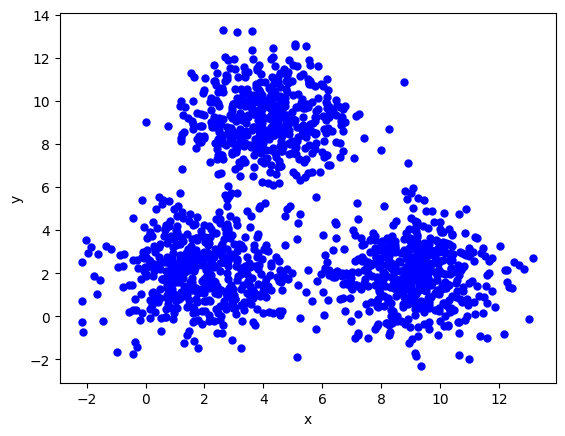

[[11.58976357  0.6151823 ]
 [ 2.10584028  3.36456963]
 [ 4.43309937  7.38454497]]


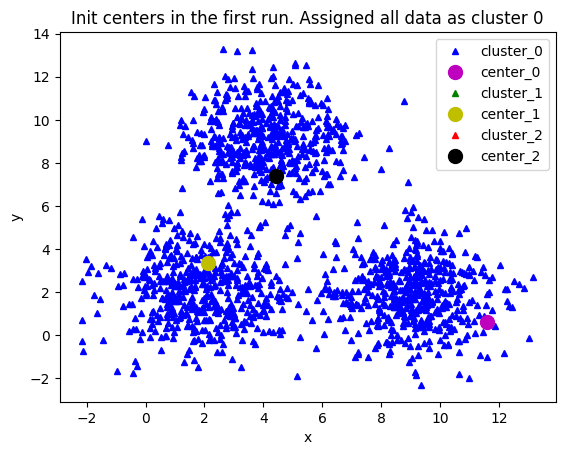

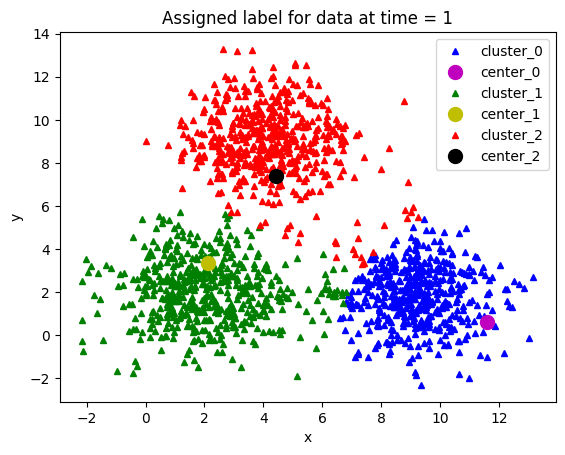

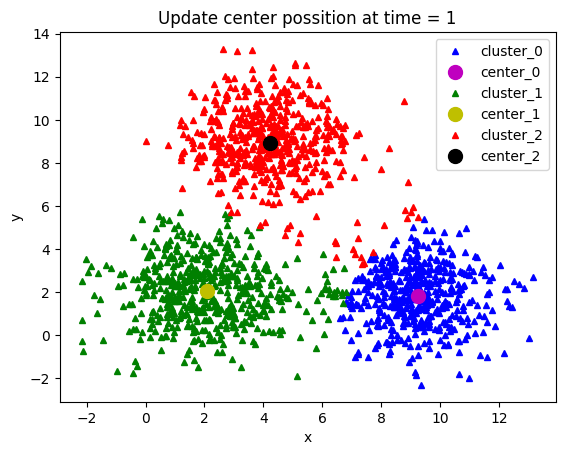

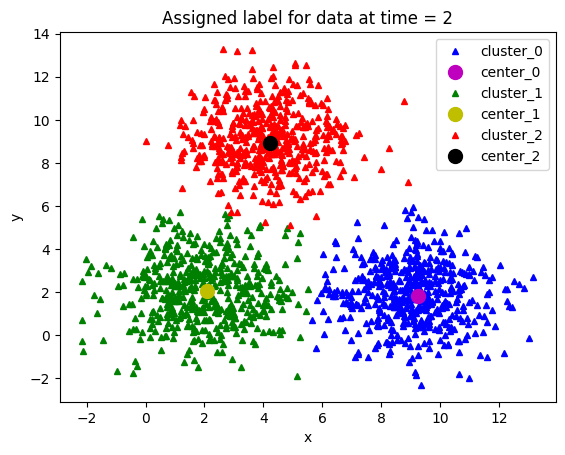

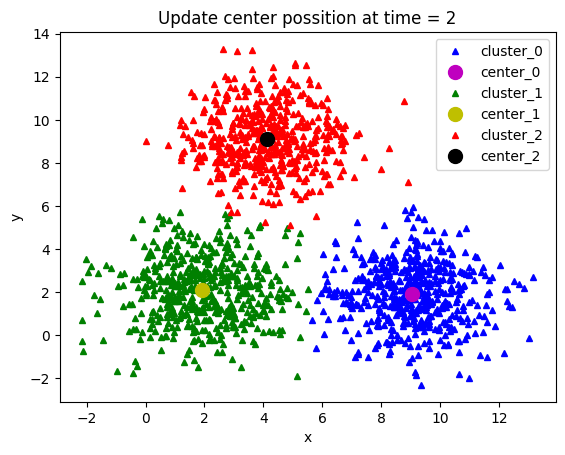

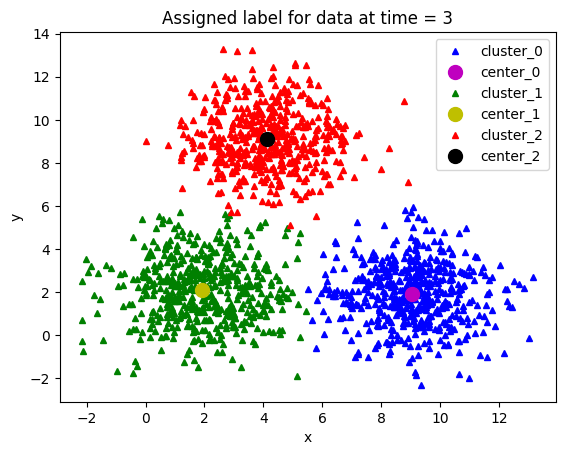

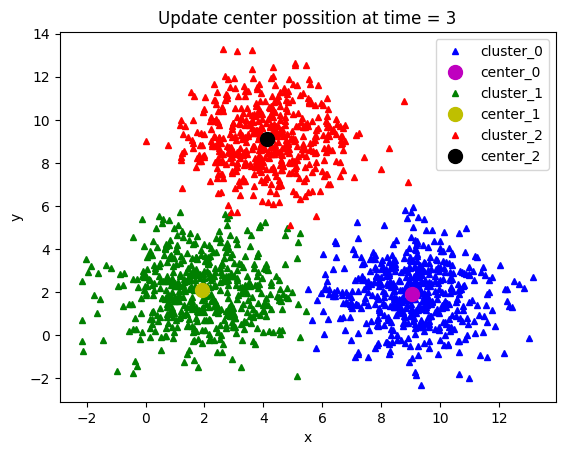

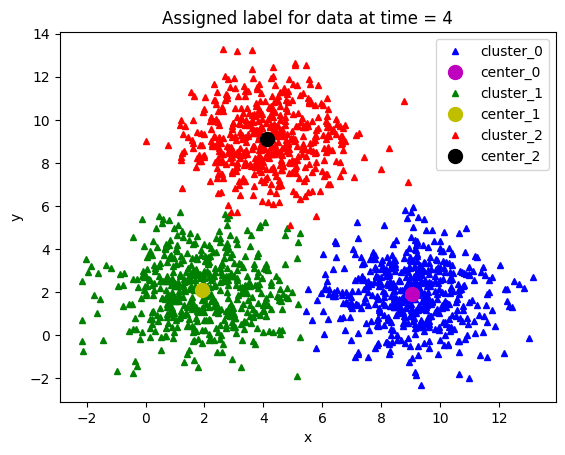

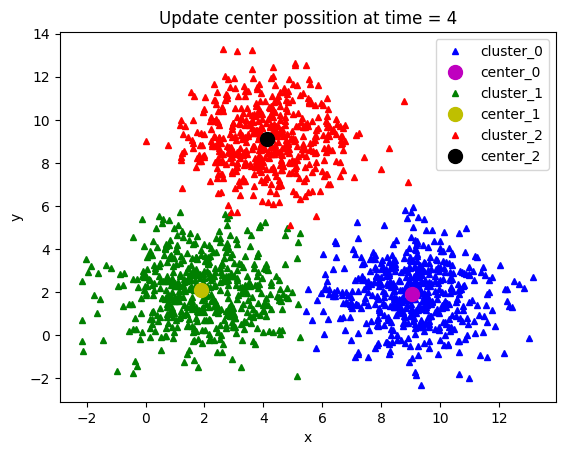

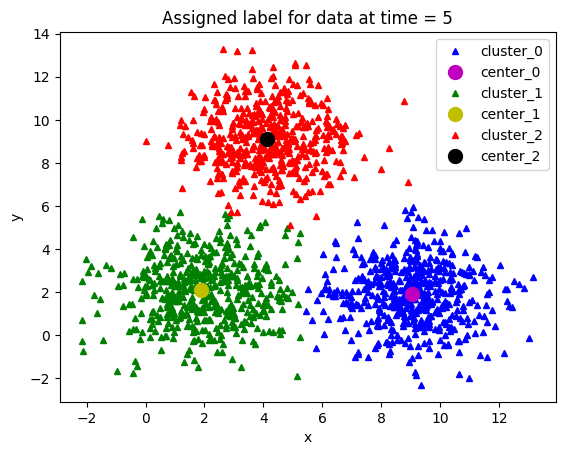

Done! Kmeans has converged after 4 times
[[9.03046425 1.91503835]
 [1.89697725 2.10886404]
 [4.11351364 9.13239807]]


In [5]:
# K-Means

import numpy as np # thư viện tính toán toán học
import matplotlib.pyplot as plt # visualize data sử dụng đồ thị
from scipy.spatial.distance import cdist # Hỗ trợ tính khoảng cách

means = [[2, 2], [9, 2], [4, 9]]
cov = [[2, 0], [0, 2]]
n_samples = 500
n_cluster = 3

X0 = np.random.multivariate_normal(means[0], cov, n_samples)
X1 = np.random.multivariate_normal(means[1], cov, n_samples)
X2 = np.random.multivariate_normal(means[2], cov, n_samples)

X = np.concatenate((X0, X1, X2), axis = 0)

plt.xlabel('x')
plt.ylabel('y')
plt.plot(X[:, 0], X[:, 1], 'bo', markersize=5)
plt.plot()
plt.show()

def kmeans_init_centers(X, n_cluster):

  # random k index beetween 0 and shape(X) without duplicate index.
  # Then return X[index] as cluster

  return X[np.random.choice(X.shape[0], n_cluster, replace=False)]

def kmeans_predict_labels(X, centers):

  D = cdist(X, centers)

  # return index of the closest center

  return np.argmin(D, axis = 1)

def kmeans_update_centers(X, labels, n_cluster):

  centers = np.zeros((n_cluster, X.shape[1]))

  for k in range(n_cluster):

    # collect all points assigned to the k-th cluster

    Xk = X[labels == k, :]

    # take average

    centers[k,:] = np.mean(Xk, axis = 0)

  return centers

def kmeans_has_converged(centers, new_centers):

  # return True if two sets of centers are the same

  return (
      set([tuple(a) for a in centers]) ==
      set([tuple(a) for a in new_centers])
  )

# Hàm này dùng để vẽ dữ liệu lên đồ thị
# Random color chỉ làm việc với k <= 4
# Nếu bạn thay đổi k > 4, hãy sửa lại phần random color nhé
# Chỉ sử dụng trong bài toán này thôi nhé.

def kmeans_visualize(X, centers, labels, n_cluster, title):

  plt.xlabel('x')  # label trục x
  plt.ylabel('y')  # label trục y
  plt.title(title)  # title của đồ thị

  plt_colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'w']

  for i in range(n_cluster):

    data = X[labels == i]

    plt.plot(
        data[:, 0],
        data[:, 1],
        plt_colors[i] + '^',
        markersize=4,
        label='cluster_' + str(i)
    )

    plt.plot(
        centers[i][0],
        centers[i][1],
        plt_colors[i + 4] + 'o',
        markersize=10,
        label='center_' + str(i)
    )

  plt.legend()
  plt.show()

def kmeans(init_centes, init_labels, X, n_cluster):

  centers = init_centes
  labels = init_labels
  times = 0

  while True:

    labels = kmeans_predict_labels(X, centers)

    kmeans_visualize(
        X,
        centers,
        labels,
        n_cluster,
        'Assigned label for data at time = ' + str(times + 1)
    )

    new_centers = kmeans_update_centers(X, labels, n_cluster)

    if kmeans_has_converged(centers, new_centers):
      break

    centers = new_centers

    kmeans_visualize(
        X,
        centers,
        labels,
        n_cluster,
        'Update center possition at time = ' + str(times + 1)
    )

    times += 1

  return (centers, labels, times)

init_centers = kmeans_init_centers(X, n_cluster)

print(init_centers)  # In ra tọa độ khởi tạo ban đầu của các tâm cụm

init_labels = np.zeros(X.shape[0])

kmeans_visualize(
    X,
    init_centers,
    init_labels,
    n_cluster,
    'Init centers in the first run. Assigned all data as cluster 0'
)

centers, labels, times = kmeans(init_centers, init_labels, X, n_cluster)

print('Done! Kmeans has converged after', times, 'times')

print(centers)


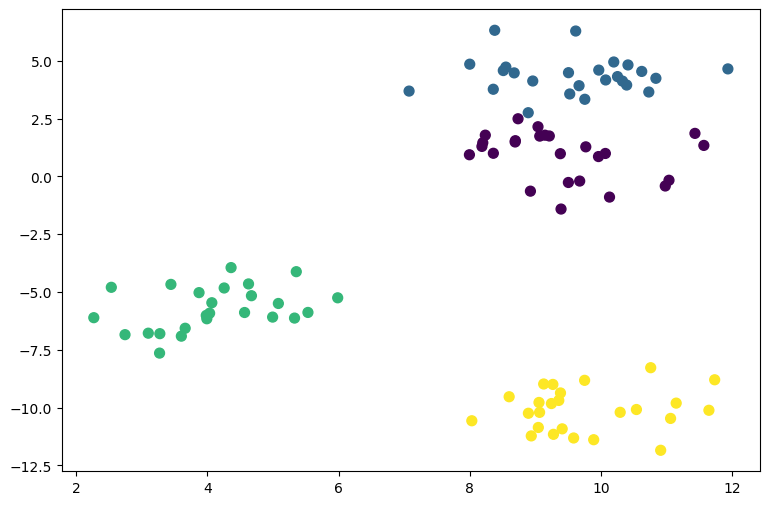

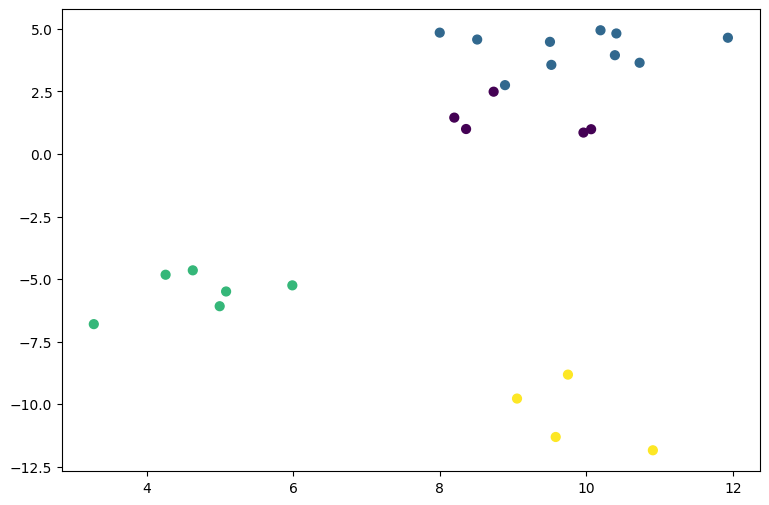

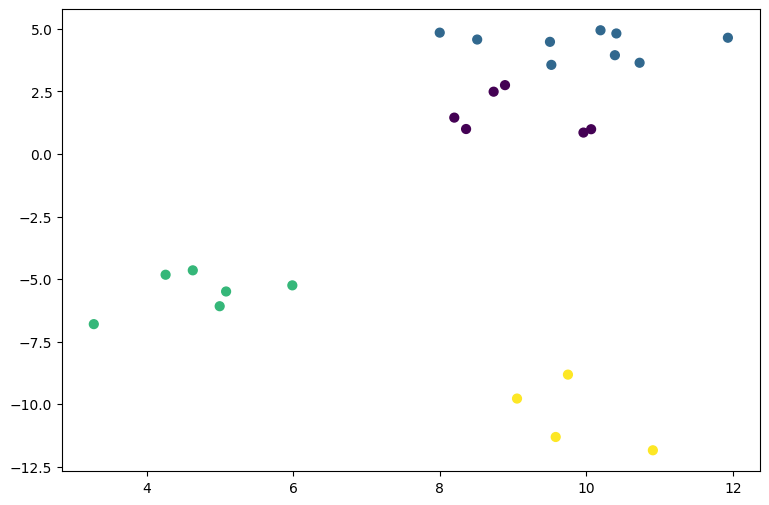

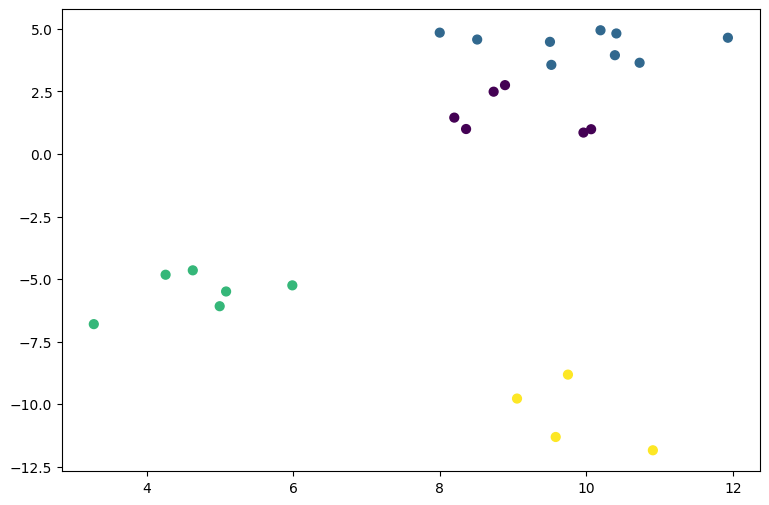

{'n_neighbors': np.int64(2)}
[0]


In [8]:
# K-NN

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  # datavisualization
from sklearn.datasets import make_blobs  # synthetic dataset
from sklearn.neighbors import KNeighborsClassifier  # kNN classifier
from sklearn.model_selection import train_test_split  # train and test sets

X,y = make_blobs(n_samples = 100, n_features = 2, centers = 4, cluster_std = 1, random_state = 4)

plt.figure(figsize=(9, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, marker='o', s=50)
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=0)

plt.figure(figsize = (9,6))
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, marker= 'o', s=40)
plt.show()

knn5 = KNeighborsClassifier(5)  # k=5
knn5.fit(X_train, y_train)

y_pred_5 = knn5.predict(X_test)

plt.figure(figsize = (9,6))
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred_5, marker= 'o', s=40)
plt.show()

knn1 = KNeighborsClassifier(1)  # k=1
knn1.fit(X_train, y_train)

y_pred_1 = knn1.predict(X_test)

plt.figure(figsize = (9,6))
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred_1, marker= 'o', s=40)
plt.show()

from sklearn.model_selection import GridSearchCV

knn_grid = GridSearchCV(
    estimator = KNeighborsClassifier(),
    param_grid={'n_neighbors': np.arange(1,10)},
    cv=5
)

knn_grid.fit(X,y)

print (knn_grid.best_params_)

def KNN(X_train,X_test,y_train,k):

    num_test = X_test.shape[0] # số lượng dữ liệu test
    num_train = X_train.shape[0] # số lượng dữ liệu train

    # y_pred là một ma trận, mỗi hàng tương ứng là khoảng cách
    # của một điểm dữ liệu trong tập test đối với tất cả
    # các điểm dữ liệu trong tập train

    y_pred = np.zeros((num_test,num_train))

    # duyệt qua mỗi điểm trong tập test

    for i in range(num_test):

        # tương ứng một điểm trong tập test
        # sẽ duyêt qua hết bộ train

        for j in range(num_train):

            # tính khoảng cách tới tập train

            y_pred[i,j] = np.sqrt(
                np.sum(
                    np.power(X_test[i,:]-X_train[j,:],2)
                )
            )

    results = []

    # sắp xếp theo chiều tăng dần khoảng cách

    for i in range(len(y_pred)):

        zipped = zip(y_pred[i,:],y_train)

        res = sorted(zipped,key = lambda x:x[0])

        results_topk = res[:k]

        # Đếm số lượng của mỗi class

        classes = {}

        for _,j in results_topk:

            j = int(j)

            if j not in classes:
                classes[j] = 1

            else:
                classes[j] = classes[j] + 1

        # trả về class có số lượng nhiều nhất

        results.append(max(classes,key = classes.get))

    return np.array(results)

(X,y) = make_blobs(
    n_samples = 500,
    n_features = 2,
    centers = 4,
    cluster_std = 1,
    random_state = 4
)

X_test=np.array([(1,3)])

results = KNN(X,X_test,y,3)

print (results)


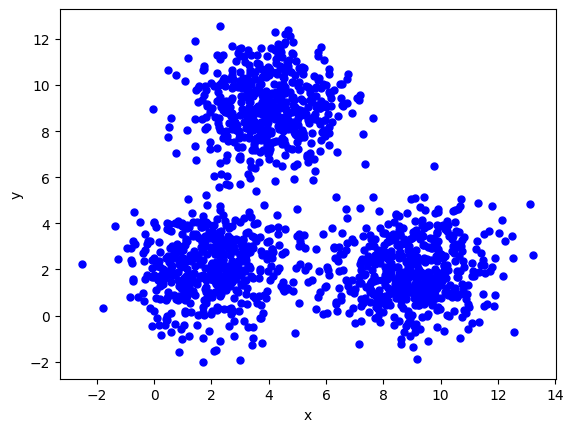

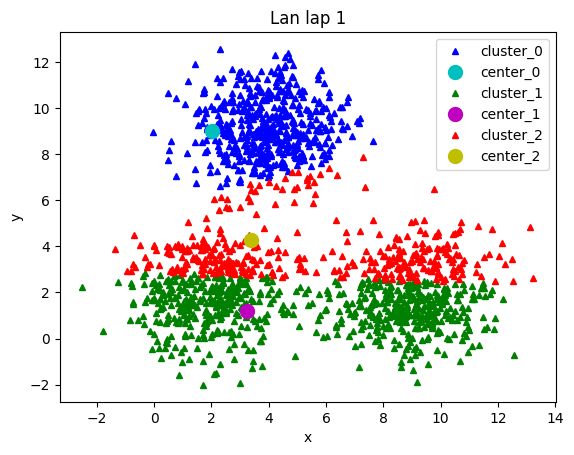

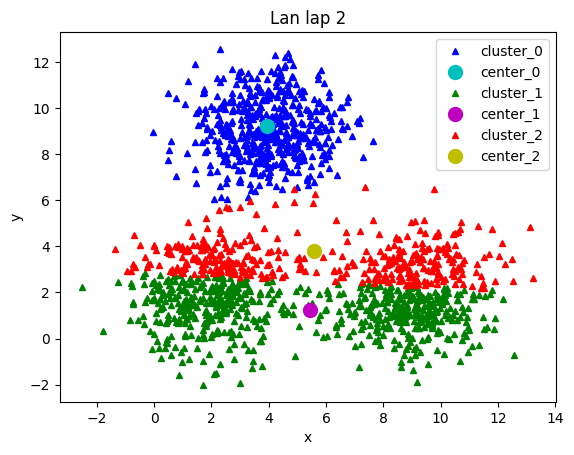

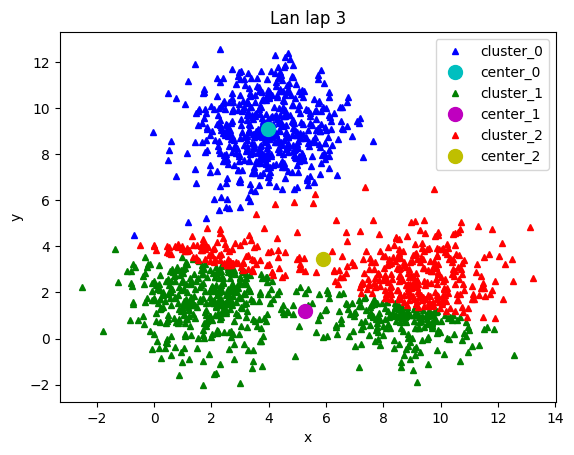

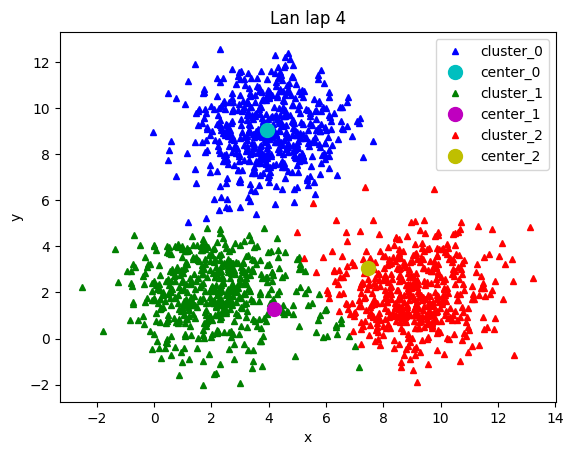

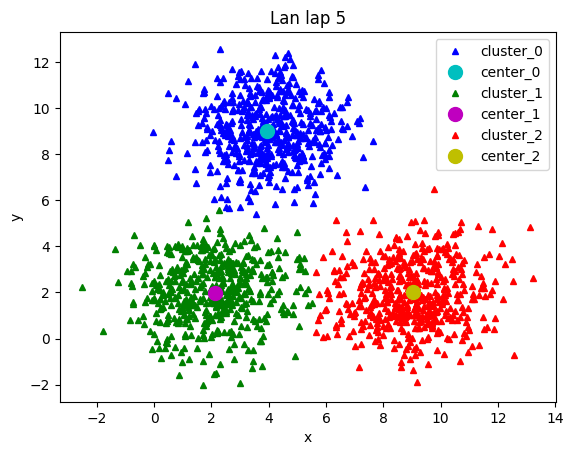

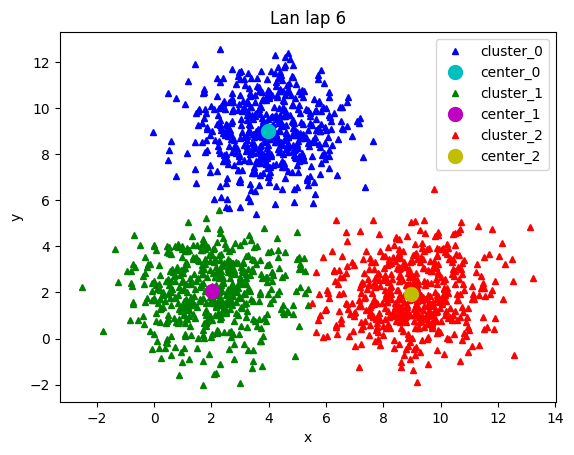

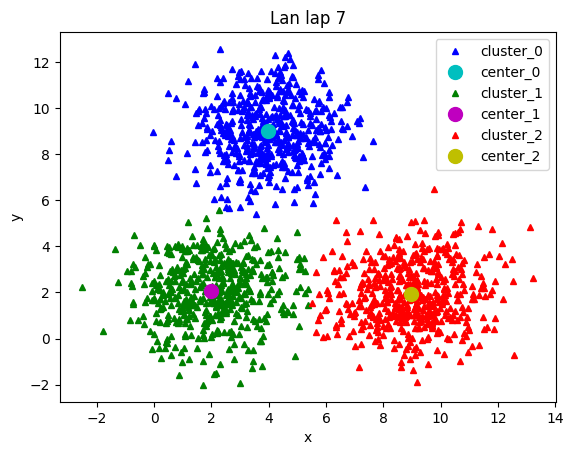

Kmeans da hoi tu sau 6 lan lap

Tam cum:

[[3.97408342 9.02471756]
 [1.99591982 2.06065888]
 [8.95438747 1.93784569]]


In [6]:
# Bài 1

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

means = [[2, 2], [9, 2], [4, 9]]
cov = [[2, 0], [0, 2]]

n_samples = 500
k = 3

A = np.random.multivariate_normal(means[0], cov, n_samples)
B = np.random.multivariate_normal(means[1], cov, n_samples)
C = np.random.multivariate_normal(means[2], cov, n_samples)

X = np.concatenate((A, B, C), axis = 0)

plt.xlabel("x")
plt.ylabel("y")

plt.plot(X[:,0], X[:,1], 'bo', markersize = 5)

plt.show()

def createCenter(X, k):

    index = np.random.choice(
        X.shape[0],
        k,
        replace = False
    )

    return X[index]

def predictLabel(X, centers):

    D = cdist(X, centers)

    return np.argmin(D, axis = 1)

def updateCenter(X, labels, k):

    centers = np.zeros((k, X.shape[1]))

    for i in range(k):

        data = X[labels == i]

        centers[i] = np.mean(data, axis = 0)

    return centers

def checkConverged(oldCenters, newCenters):

    return (
        set([tuple(x) for x in oldCenters]) ==
        set([tuple(x) for x in newCenters])
    )

def drawKmeans(X, centers, labels, k, title):

    colors = ['b', 'g', 'r', 'c', 'm', 'y']

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)

    for i in range(k):

        data = X[labels == i]

        plt.plot(
            data[:,0],
            data[:,1],
            colors[i] + '^',
            markersize = 4,
            label = 'cluster_' + str(i)
        )

        plt.plot(
            centers[i][0],
            centers[i][1],
            colors[i + 3] + 'o',
            markersize = 10,
            label = 'center_' + str(i)
        )

    plt.legend()

    plt.show()

def kmeans(X, k):

    centers = createCenter(X, k)

    labels = np.zeros(X.shape[0])

    step = 0

    while True:

        labels = predictLabel(X, centers)

        drawKmeans(
            X,
            centers,
            labels,
            k,
            'Lan lap ' + str(step + 1)
        )

        newCenters = updateCenter(X, labels, k)

        if checkConverged(centers, newCenters):
            break

        centers = newCenters

        step += 1

    return centers, labels, step

centers, labels, step = kmeans(X, k)

print("Kmeans da hoi tu sau", step, "lan lap")

print("\nTam cum:\n")

print(centers)


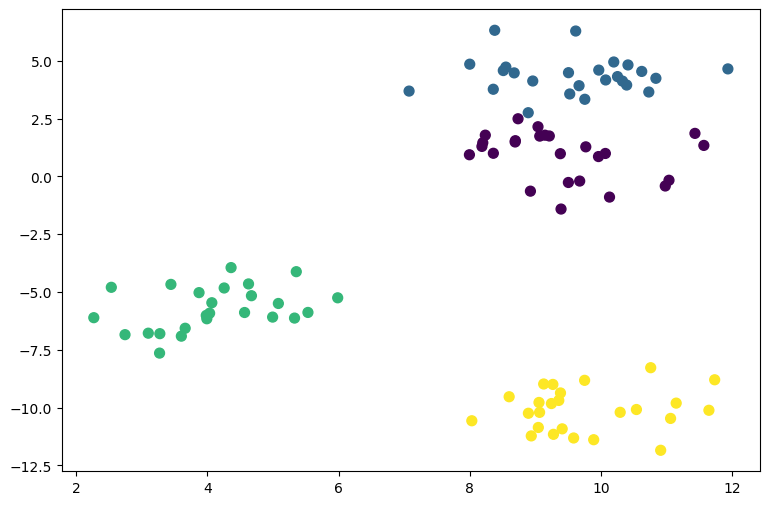

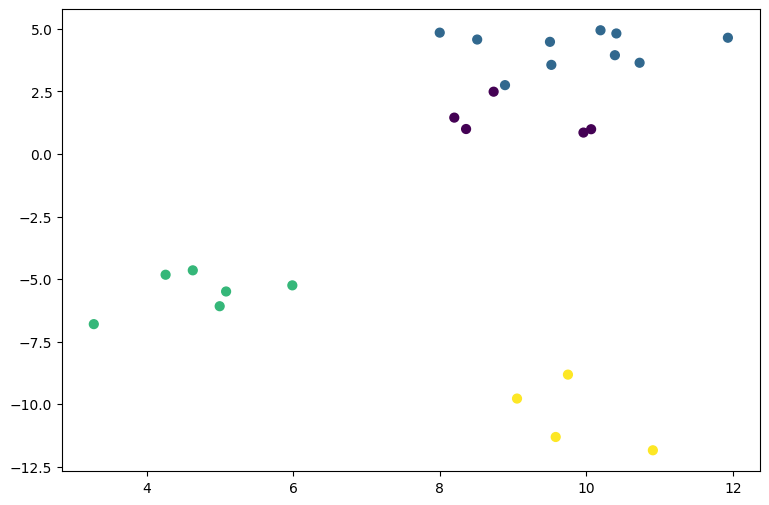

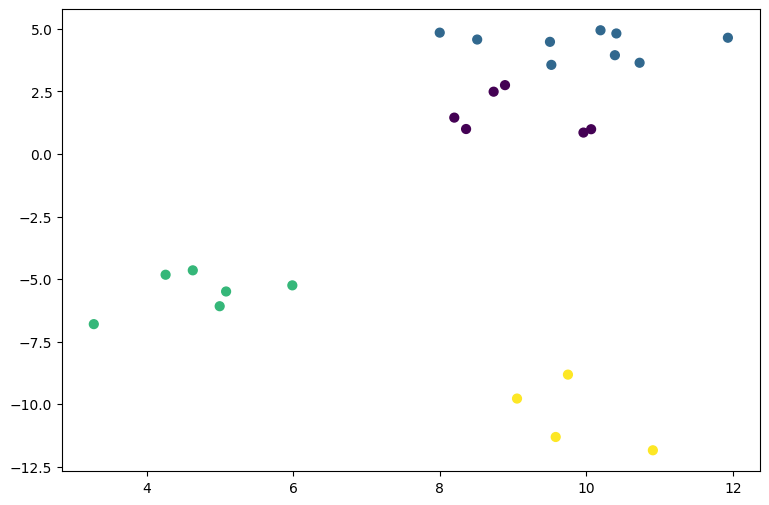

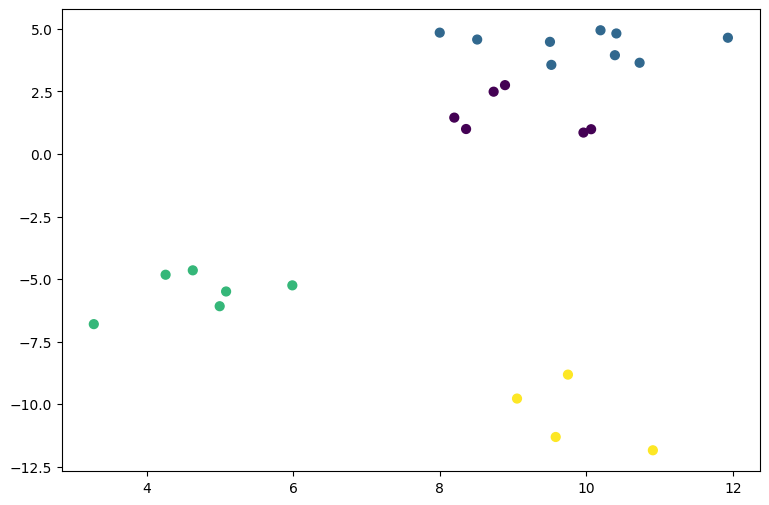

Gia tri k tot nhat:
{'n_neighbors': np.int64(2)}

Ket qua du doan:
[0]


In [9]:
# Bài 2

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

X, y = make_blobs(
    n_samples = 100,
    n_features = 2,
    centers = 4,
    cluster_std = 1,
    random_state = 4
)

plt.figure(figsize = (9,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c = y,
    marker = 'o',
    s = 50
)

plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state = 0
)

plt.figure(figsize = (9,6))

plt.scatter(
    X_test[:,0],
    X_test[:,1],
    c = y_test,
    marker = 'o',
    s = 40
)

plt.show()

model3 = KNeighborsClassifier(n_neighbors = 3)

model3.fit(X_train, y_train)

predict3 = model3.predict(X_test)

plt.figure(figsize = (9,6))

plt.scatter(
    X_test[:,0],
    X_test[:,1],
    c = predict3,
    marker = 'o',
    s = 40
)

plt.show()

model7 = KNeighborsClassifier(n_neighbors = 7)

model7.fit(X_train, y_train)

predict7 = model7.predict(X_test)

plt.figure(figsize = (9,6))

plt.scatter(
    X_test[:,0],
    X_test[:,1],
    c = predict7,
    marker = 'o',
    s = 40
)

plt.show()

grid = GridSearchCV(
    estimator = KNeighborsClassifier(),
    param_grid = {'n_neighbors': np.arange(1,10)},
    cv = 5
)

grid.fit(X,y)

print("Gia tri k tot nhat:")

print(grid.best_params_)

def MyKNN(X_train, X_test, y_train, k):

    test_size = X_test.shape[0]

    train_size = X_train.shape[0]

    distance = np.zeros((test_size, train_size))

    for i in range(test_size):

        for j in range(train_size):

            distance[i,j] = np.sqrt(
                np.sum(
                    np.power(X_test[i,:] - X_train[j,:],2)
                )
            )

    result = []

    for i in range(len(distance)):

        combine = zip(distance[i,:], y_train)

        sort_data = sorted(combine, key = lambda x:x[0])

        top_k = sort_data[:k]

        count_class = {}

        for _,j in top_k:

            j = int(j)

            if j not in count_class:

                count_class[j] = 1

            else:

                count_class[j] = count_class[j] + 1

        result.append(
            max(count_class, key = count_class.get)
        )

    return np.array(result)

(X,y) = make_blobs(
    n_samples = 500,
    n_features = 2,
    centers = 4,
    cluster_std = 1,
    random_state = 4
)

X_test = np.array([(1,3)])

result = MyKNN(X, X_test, y, 3)

print("\nKet qua du doan:")

print(result)


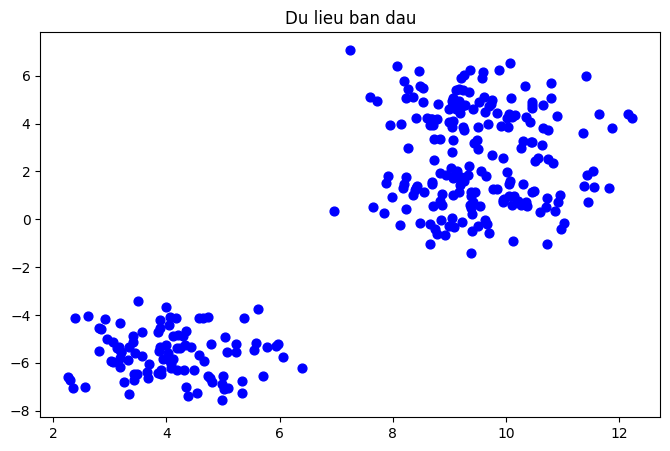

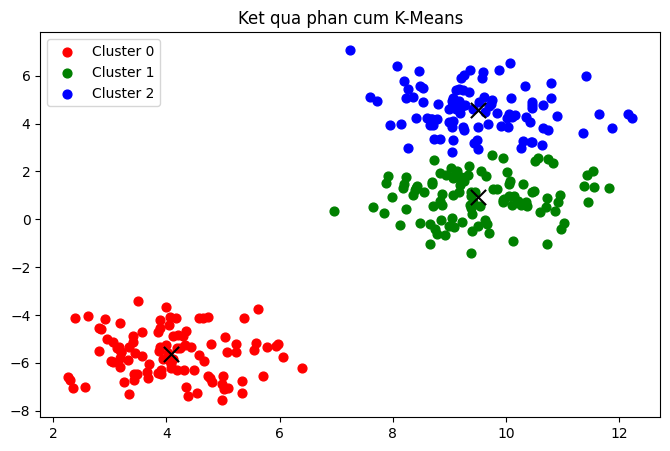

Tam cum:
[[ 4.08201351 -5.61735088]
 [ 9.51535594  0.92054692]
 [ 9.51063279  4.58147062]]


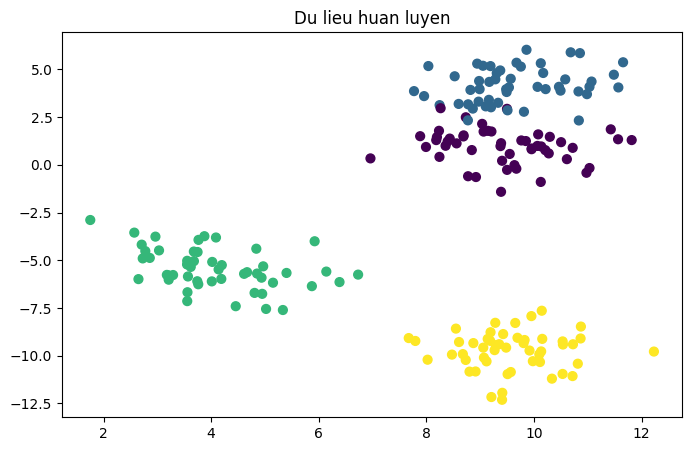

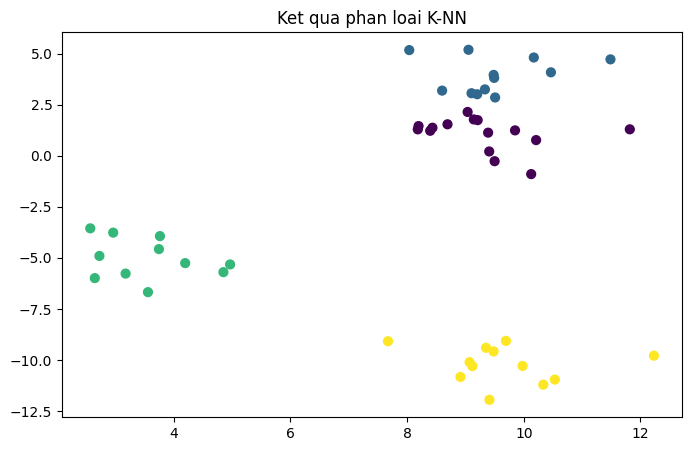

Diem moi: [[1 3]]
Du doan thuoc lop: [0]


In [12]:
# Bài 3

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from scipy.spatial.distance import cdist
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# =========================
# DEMO K-MEANS
# =========================

X, y = make_blobs(
    n_samples = 300,
    n_features = 2,
    centers = 3,
    cluster_std = 1,
    random_state = 4
)

plt.figure(figsize = (8,5))

plt.scatter(
    X[:,0],
    X[:,1],
    c = 'blue',
    s = 40
)

plt.title("Du lieu ban dau")

plt.show()

def createCenter(X, k):

    index = np.random.choice(
        X.shape[0],
        k,
        replace = False
    )

    return X[index]

def predictLabel(X, centers):

    D = cdist(X, centers)

    return np.argmin(D, axis = 1)

def updateCenter(X, labels, k):

    centers = np.zeros((k, X.shape[1]))

    for i in range(k):

        data = X[labels == i]

        centers[i] = np.mean(data, axis = 0)

    return centers

def checkConverged(oldCenters, newCenters):

    return (
        set([tuple(x) for x in oldCenters]) ==
        set([tuple(x) for x in newCenters])
    )

def Kmeans(X, k):

    centers = createCenter(X, k)

    while True:

        labels = predictLabel(X, centers)

        newCenters = updateCenter(X, labels, k)

        if checkConverged(centers, newCenters):
            break

        centers = newCenters

    return centers, labels

centers, labels = Kmeans(X, 3)

plt.figure(figsize = (8,5))

colors = ['red', 'green', 'blue']

for i in range(3):

    data = X[labels == i]

    plt.scatter(
        data[:,0],
        data[:,1],
        c = colors[i],
        s = 40,
        label = 'Cluster ' + str(i)
    )

    plt.scatter(
        centers[i][0],
        centers[i][1],
        c = 'black',
        s = 120,
        marker = 'x'
    )

plt.title("Ket qua phan cum K-Means")

plt.legend()

plt.show()

print("Tam cum:")

print(centers)

# =========================
# DEMO K-NN
# =========================

X, y = make_blobs(
    n_samples = 200,
    n_features = 2,
    centers = 4,
    cluster_std = 1,
    random_state = 4
)

plt.figure(figsize = (8,5))

plt.scatter(
    X[:,0],
    X[:,1],
    c = y,
    s = 40
)

plt.title("Du lieu huan luyen")

plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state = 0
)

model = KNeighborsClassifier(n_neighbors = 3)

model.fit(X_train, y_train)

predict = model.predict(X_test)

plt.figure(figsize = (8,5))

plt.scatter(
    X_test[:,0],
    X_test[:,1],
    c = predict,
    s = 40
)

plt.title("Ket qua phan loai K-NN")

plt.show()

new_point = np.array([[1,3]])

result = model.predict(new_point)

print("Diem moi:", new_point)

print("Du doan thuoc lop:", result)